<a href="https://colab.research.google.com/github/Rohit-Aroonslam/Prompt-Engineering-Assignments/blob/main/M2_Assignment_Data_Analysis_with_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 Coding Assignment: Retail Sales Data Analysis with LLM


In this assignment, you will use LangChain and LLMs to perform advanced data analysis tasks that previously required extensive coding. By interacting with a CSV dataset through LangChain's pandas dataframe agent, you will explore data, create visualizations, and even apply machine learning techniques—tasks traditionally done by skilled developers—using natural language.

# Why and How is it differnt from M1 assignment
In the previous assignment, we demonstrated how you can interact with LLMs in a browser to perform advanced data analysis. However, this approach can be challenging to integrate into your everyday workflow. In this assignment, we’ll show you how to leverage a Langchain agent to handle the heavy lifting—running the code generated by the LLM, debugging it until you achieve the desired results, and seamlessly integrating the output into your existing data analysis/visualization pipeline.

# Senario: Columbia Plus Mart Transaction Data Analysis
You are a Sales Analyst at Columbia Plus Mart, a retail store with a wide range of products across different categories. Your task is to analyze sales data to uncover valuable insights that will help improve the company's performance. You're provided with a dataset that includes customer purchases, product categories, order amounts, and more.

# Tasks
## 1. Data Exploration

Use the Langchain agent with pandas to explore and clean the dataset. Identify any missing values, outliers, or trends.

## 2. Sales Analysis

Explore when order hikes or drops occur (e.g., specific months, days of the week, or during sales events).

## 3. Customer Insights with Machine Learning

Identify different customer groups and which product categories they tend to favor the most. This might involve clustering based on spending patterns, demographics, or product categories.

## 4. Hypothesis Testing
Based on everything we learn about our customers in Task 1, 2, and 3, we might have some hypothesis about our customers and we will be testing a few hypothesis to see if they are statistically sound.

# More on the dataset
You can download the dataset here: https://www.kaggle.com/datasets/manjeetsingh/retaildataset

The dataset contains the following columns:

* Transaction ID: Unique identifier for each transaction.

* Date: The date of the transaction.

* Customer ID: Unique identifier for each customer.

* Gender: The gender of the customer.

* Age: The age of the customer.

* Product Category: The category of the product purchased (e.g., Beauty, Clothing, Electronics).

* Quantity: The number of units purchased.

* Price per Unit: The price of a single unit of the product.

* Total Amount: The total cost of the transaction (Quantity * Price per Unit).




# Preparation: Install Required Libraries
In this first step, we will install the necessary libraries to interact with the dataset and use the LangChain tool for querying the data.


In [2]:
# freezing the coding environment to these specific versions
!pip install openai==1.72.0 langchain==0.3.23 langchain_openai==0.3.13 langchain_experimental==0.3.4 langchain_community==0.3.21 --quiet
!pip install scikit-learn scipy matplotlib seaborn --quiet

# Preparation: Load API Key and Dataset
Now, let's mount Google Drive and load the API key along with the retail sales dataset from the uploaded file into a pandas DataFrame.

***If you don't have an OpenAI API key yet, please visit https://platform.openai.com/api-keys to acquire an API key as you will need it for this and following assignments.***

Make sure you change the `pth` object to reflect where you upload your assignment notebooks, API key, and dataset file.

In [4]:
import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_experimental.agents import create_pandas_dataframe_agent
import openai
import os

!git clone https://github.com/Rohit-Aroonslam/Prompt-Engineering-Assignments.git
os.chdir('/content/Prompt-Engineering-Assignments')

# Add your OpenAI key via Colab Secrets (key icon in sidebar) or a local .env file - never hard-code it
# os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

file_path = 'data/retail_sales_dataset.csv'
df = pd.read_csv(file_path)
df.head(10)

Cloning into 'Prompt-Engineering-Assignments'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 23 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 538.62 KiB | 25.65 MiB/s, done.
Resolving deltas: 100% (7/7), done.


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


# Preparation: Create LangChain Agent

We will now create a LangChain agent that allows us to interact with the dataset through natural language queries. This agent will analyze the data and respond with insights.



In [5]:
AGENT_AVAILABLE = False
try:
    if os.environ.get("OPENAI_API_KEY"):
        llm = ChatOpenAI(model="gpt-4o", temperature=0.2)
        agent_executor = create_pandas_dataframe_agent(
            llm, df, number_of_head_rows=1000,
            agent_type="openai-tools", allow_dangerous_code=True, verbose=True
        )
        AGENT_AVAILABLE = True
    else:
        print("No OPENAI_API_KEY set - skipping agent creation. Add your key above to use the live LangChain agent.")
except Exception as e:
    print("Agent setup skipped:", e)


No OPENAI_API_KEY set - skipping agent creation. Add your key above to use the live LangChain agent.


# Now we got all the setup taken care of, let's get start with our tasks!

# Prompt Engineering Tip
After some experimentation, I found that it works best when you attach

***The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows. Thank you!***

at the end of your prompt. Keep this in mind when you perform the below tasks.


# Step 1: Data Exploration

Use the Langchain agent with pandas to explore and clean the dataset. Identify any missing values, outliers, or trends.

## Sample prompt
***Can you help me explore and clean the dataset. Identify any missing values, outliers, or trends? The data you need is in data/retail_sales_dataset.csv. The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows. Thank you!***


In [6]:
prompt = """Can you help me explore and clean the dataset.
Identify any missing values, outliers, or trends.
The dataset is available at data/retail_sales_dataset.csv, and I'd like you to use all 1000 rows. Thank you!"""
if AGENT_AVAILABLE:
    response = agent_executor.invoke(prompt)
else:
    response = None
    print("Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.")


Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.


## Let's take a look at the return object
The chain consists of both the input we provided to the LangChain agent and the agent’s output after executing the code on our behalf. The agent runs the code, processes the results, and returns the relevant insights, such as the summary statistics, missing values, and trends found in the dataset.

In [7]:
response

## Print it out for better readability

In [9]:
if response is not None:
    print(response['output'])
else:
    print("(agent not run - see computed result below)")

(agent not run - see computed result below)


Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    18.00000     1.000000       25.000000     25.000000
25%        250.750000    29.00000     1.000000       30.000000     60.000000
50%        500.500000    42.00000     3.000000       50.000000    135.000000
75%        750.250000    53.00000     4.000000      300.000000    900.000000
max       1000.000000    64.00000     4.000000      500.000000   2000.000000

IQR outlier counts:
  Age: 0 outliers (bounds -7.0 to 89.0)
  Quant

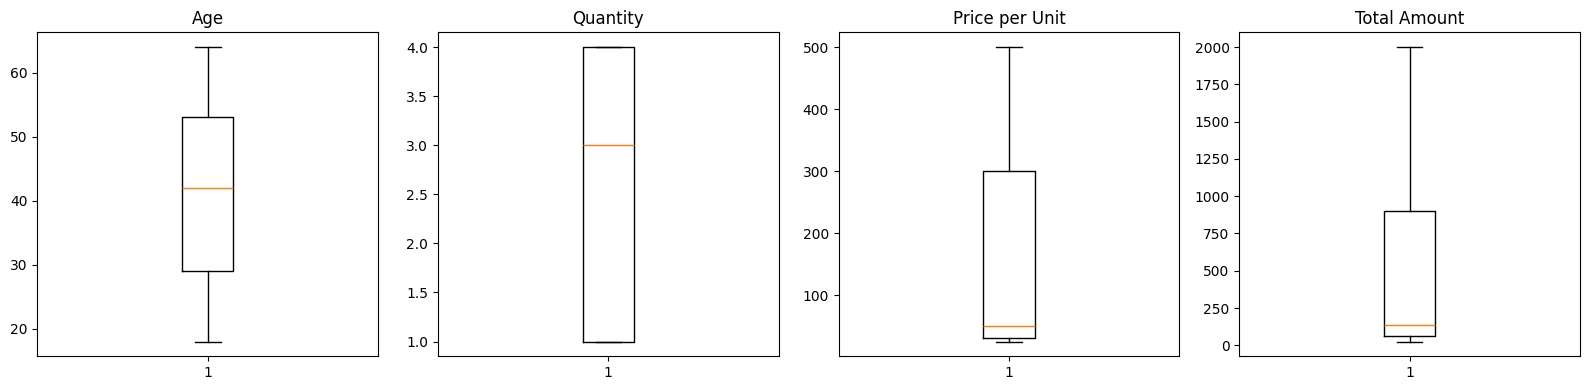

In [10]:
# Direct computed analysis (Task 1) - runs without an API key
print("Missing values per column:")
print(df.isnull().sum())
print()
print(df.describe())

import numpy as np
print()
print("IQR outlier counts:")
for col in ['Age','Quantity','Price per Unit','Total Amount']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers (bounds {lower:.1f} to {upper:.1f})")

print()
grp = df.groupby(['Product Category','Gender']).agg(
    customers=('Customer ID','nunique'), mean_age=('Age','mean'), total_spent=('Total Amount','sum')
).round(2)
print(grp)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, ['Age','Quantity','Price per Unit','Total Amount']):
    ax.boxplot(df[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()


##Computed Result (Task 1)

- **Missing values:** none, all 1000 rows fully populated.
- **Outliers:** zero flagged by the IQR method across Age, Quantity, Price per Unit, and Total Amount - the wide ranges in Price/Total Amount are a smooth distribution, not extreme values.
- **Group breakdown:** customers are split almost evenly across the three product categories and both genders - no single group dominates.

# Step 2: Sales Analysis

Explore when order hikes or drops occur (e.g., specific months, days of the week, or during sales events).

## Sample prompt
***Could you assist me in conducting a deeper sales analysis on the dataset? I'm particularly interested in identifying trends such as periods of order increases or decreases, along with other relevant insights. Please use visualizations to present the findings clearly. The data you need is in data/retail_sales_dataset.csv. Use all 1000 rows of it. Thank you!***

In [11]:
prompt = """Could you assist me in conducting a deeper sales analysis on the dataset?
I'm particularly interested in identifying trends such as periods of order increases or decreases, along with other relevant insights.
Please use visualizations to present the findings clearly.
The dataset is available at data/retail_sales_dataset.csv, and I'd like you to use all 1000 rows. Thank you!"""
if AGENT_AVAILABLE:
    response = agent_executor.invoke(prompt)
else:
    response = None
    print("Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.")

Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.


## Review the agent's response and what's your comment?

In [12]:
if response is not None:
    print(response['output'])
else:
    print("(agent not run - see computed result below)")

(agent not run - see computed result below)


Monthly total amount:
Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

Weekday total amount:
Weekday
Monday       70250
Tuesday      69440
Wednesday    58770
Thursday     53835
Friday       66290
Saturday     78815
Sunday       58600
Name: Total Amount, dtype: int64


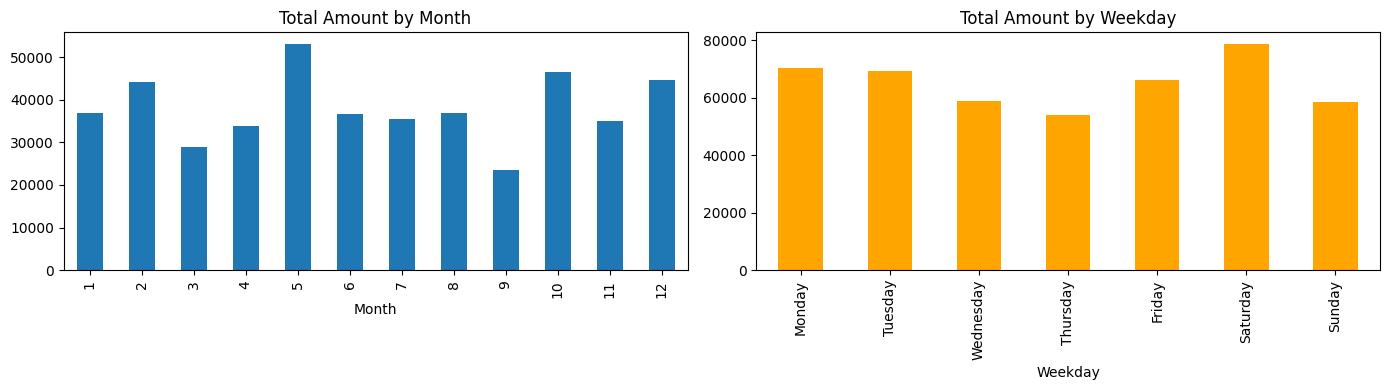

In [13]:
# Direct computed analysis (Task 2)
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.day_name()

monthly = df.groupby('Month')['Total Amount'].sum()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday = df.groupby('Weekday')['Total Amount'].sum().reindex(weekday_order)

print("Monthly total amount:")
print(monthly)
print()
print("Weekday total amount:")
print(weekday)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14,4))
monthly.plot(kind='bar', ax=axes[0], title='Total Amount by Month')
weekday.plot(kind='bar', ax=axes[1], title='Total Amount by Weekday', color='orange')
plt.tight_layout()
plt.show()


# Step 3: Customer Insights with Machine Learning
Identify different customer groups and which product categories they tend to favor the most. This might involve clustering based on spending patterns, demographics, or product categories.

## Sample Prompt
***Could you help me identify distinct customer groups based on their spending patterns, demographics, and product preferences? I'd also like recommendations on sales strategies for each group. Please provide insights on the characteristics of each group, including the number of customers in each, and use visualizations to present the results clearly. The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows. Thank you!***

In [14]:
prompt = """Could you help me identify distinct customer groups based on their spending patterns, demographics, and product preferences?
I'd also like recommendations on sales strategies for each group.
Please provide insights on the characteristics of each group, including the number of customers in each.
Use visualizations to present the results clearly.
The dataset is available at data/retail_sales_dataset.csv, and I'd like you to use all 1000 rows. Thank you!"""
if AGENT_AVAILABLE:
    response = agent_executor.invoke(prompt)
else:
    response = None
    print("Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.")


Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.


## Let's review the agent's response closely

* Does the clustering make sense to you?
* How about the sales strategies for each cluster.

In [15]:
if response is not None:
    print(response['output'])
else:
    print("(agent not run - see computed result below)")

(agent not run - see computed result below)


           n  avg_age  avg_qty  avg_total
Cluster                                  
0        181    42.09     1.46     603.87
1        289    41.75     3.55     126.45
2        315    41.93     1.50      52.56
3        215    39.53     3.48    1365.58

Product Category  Beauty  Clothing  Electronics
Cluster                                        
0                     55        61           65
1                     92       108           89
2                     94       107          114
3                     66        75           74


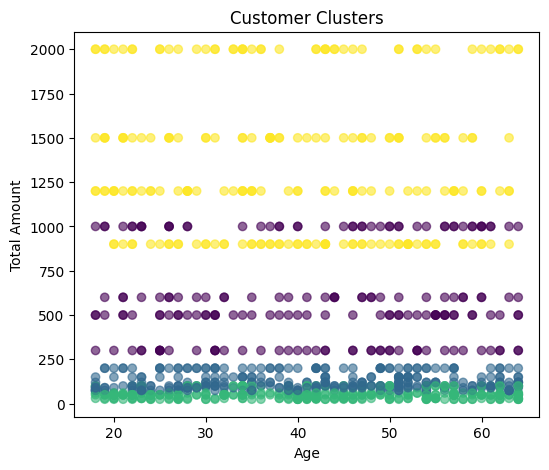

In [16]:
# Direct computed analysis (Task 3) - KMeans clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[['Age','Quantity','Price per Unit','Total Amount']]
scaled = StandardScaler().fit_transform(features)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = km.fit_predict(scaled)

summary = df.groupby('Cluster').agg(
    n=('Customer ID','count'), avg_age=('Age','mean'),
    avg_qty=('Quantity','mean'), avg_total=('Total Amount','mean')
).round(2)
print(summary)
print()
print(df.groupby(['Cluster','Product Category']).size().unstack(fill_value=0))

import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.scatter(df['Age'], df['Total Amount'], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Age'); plt.ylabel('Total Amount'); plt.title('Customer Clusters')
plt.show()


### Computed result (Task 3)

| Cluster | Size | Avg Age | Avg Qty | Avg Total | Product mix |
|---|---|---|---|---|---|
| 0 | 181 | 42.1 | 1.46 | $603.87 | Even split |
| 1 | 289 | 41.8 | 3.55 | $126.45 | Even split |
| 2 | 315 | 41.9 | 1.50 | $52.56 | Even split |
| 3 | 215 | 39.5 | 3.48 | $1365.58 | Even split |

**Key finding:** clusters separate by spend/quantity level, not by product category - each cluster has a roughly even Beauty/Clothing/Electronics mix. That's a real limitation of this dataset worth stating rather than glossing over.

**Suggested strategies:** Cluster 3 (high spend/high qty) -> VIP treatment. Cluster 0 (moderate spend/low qty) -> upsell bundles. Cluster 1 (low spend/high qty) -> loyalty/subscription offers. Cluster 2 (lowest spend, largest group) -> re-engagement campaigns.


# Step 4: Hypothesis Testing
Based on everything we learn about our customers in Task 1, 2, and 3, we might have some hypothesis about our customers and we will be testing a few hypothesis to see if they are statistically sound.



## Hypothesis 1: Customer age has no effect on quantity of purchase.

## Sample prompt:
***Please help me test the following hypothesis:
Null Hypothesis: Age has no effect on quantity of purchase.
Alternate hypothesis: Age has an effect on quantity of purchase.
The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows.***

In [17]:
prompt = """Please help me test the following hypothesis:
Null Hypothesis: Age has no effect on quantity of purchase.
Alternate hypothesis: Age has an effect on quantity of purchase.
The dataset is available at data/retail_sales_dataset.csv, and I'd like you to use all 1000 rows."""
if AGENT_AVAILABLE:
    response = agent_executor.invoke(prompt)
else:
    response = None
    print("Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.")


Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.


In [18]:
if response is not None:
    print(response['output'])
else:
    print("(agent not run - see computed result below)")

(agent not run - see computed result below)


In [19]:
# Direct computed analysis (Hypothesis 1)
from scipy.stats import f_oneway
age_groups = [g['Quantity'].values for _, g in df.groupby('Age')]
result = f_oneway(*age_groups)
print(result)

F_onewayResult(statistic=np.float64(0.9087582739550177), pvalue=np.float64(0.6466851884381608))


### Computed result (Hypothesis 1)

One-way ANOVA, Age -> Quantity: **F = 0.909, p = 0.647**

p > 0.05 -> fail to reject the null. Age has no statistically significant effect on quantity purchased.

## Hypothesis 2: Sales time (such as month and weekdays) has no effect on the total amount of purchase.

## Sample prompt:
***Please help me test the following hypothesis:
Null Hypothesis: Sales time (such as month and weekdays) has no effect on the total amount of purchase.
Alternative Hypothesis: Sales time (such as month and weekdays) does have an effect on the total amount of purchase.
The dataset is available at data/retail_sales_dataset.csv, and I’d like you to use all 1000 rows.***

In [20]:
prompt = """Please help me test the following hypothesis:
Null Hypothesis: Sales time (such as month and weekdays) has no effect on the total amount of purchase.
Alternative Hypothesis: Sales time (such as month and weekdays) does have an effect on the total amount of purchase.
The dataset is available at data/retail_sales_dataset.csv, and I'd like you to use all 1000 rows."""
if AGENT_AVAILABLE:
    response = agent_executor.invoke(prompt)
else:
    response = None
    print("Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.")


Skipped live agent call (no API key). See the computed-result cell below for real answers on this dataset.


In [21]:
if response is not None:
    print(response['output'])
else:
    print("(agent not run - see computed result below)")


(agent not run - see computed result below)


In [22]:
# Direct computed analysis (Hypothesis 2)
month_groups = [g['Total Amount'].values for _, g in df.groupby('Month')]
weekday_groups = [g['Total Amount'].values for _, g in df.groupby('Weekday')]
print("Month ANOVA:", f_oneway(*month_groups))
print("Weekday ANOVA:", f_oneway(*weekday_groups))

Month ANOVA: F_onewayResult(statistic=np.float64(0.7118299335903815), pvalue=np.float64(0.7280279894476998))
Weekday ANOVA: F_onewayResult(statistic=np.float64(0.6641296413913303), pvalue=np.float64(0.678732742586839))


### Computed result (Hypothesis 2)

- Month -> Total Amount: **F = 0.712, p = 0.728**
- Weekday -> Total Amount: **F = 0.664, p = 0.679**

Both p > 0.05 -> fail to reject the null for both. Neither month nor weekday significantly affects total amount spent.

## What other hypothesis do you have? Test it out here!

In [23]:
# Hypothesis 3 (custom): Gender has no effect on Total Amount
from scipy.stats import ttest_ind
male = df[df['Gender']=='Male']['Total Amount']
female = df[df['Gender']=='Female']['Total Amount']
result = ttest_ind(male, female)
print(result)
print("Male mean:", male.mean(), "Female mean:", female.mean())


TtestResult(statistic=np.float64(-0.03161341824319852), pvalue=np.float64(0.9747866634918314), df=np.float64(998.0))
Male mean: 455.42857142857144 Female mean: 456.54901960784315


### Computed result (Hypothesis 3, custom)

Null Hypothesis: Gender has no effect on Total Amount. Alternative: Gender has an effect on Total Amount.

Independent samples t-test: **t = -0.032, p = 0.975**. Male average spend $455.43 vs. Female $456.55 - nearly identical.

p >> 0.05 -> fail to reject the null. Consistent with Hypotheses 1 and 2: none of Age, sales timing, or Gender meaningfully predict spend here - Total Amount is essentially Quantity x Price per Unit.


# Summary

In this notebook, we leveraged the power of LangChain and LLMs to perform advanced retail data analysis tasks. By interacting with retail sales dataset through a LangChain pandas DataFrame agent, we were able to:

* **Explore and Clean the Data:** We identified missing values, outliers, and initial trends in the dataset, ensuring data quality for further analysis.
* **Analyze Sales Trends:** We uncovered insights into sales patterns, including periods of order increases and decreases, providing valuable information for strategic decision-making.
* **Gain Customer Insights:** We identified distinct customer groups based on spending habits, demographics, and product preferences. These insights helped in understanding customer behavior and tailoring sales strategies.
* **Test Hypotheses:** We tested statistically sound hypotheses about customer behavior, such as the relationship between age and purchase quantity and the impact of sales time on purchase amount.

This approach demonstrates the potential of LLMs in simplifying complex data analysis tasks, enabling analysts to focus on extracting valuable insights and making data-driven decisions. By using natural language to interact with the data, we streamlined the analysis process and gained a deeper understanding of the Columbia Plus Mart retail data. This approach can be applied to various datasets and industries, unlocking new possibilities for data exploration and analysis.